In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
import seaborn as sns

In [4]:
import matplotlib.pyplot as plt

In [5]:
dataset=pd.read_csv('E:\Titanic_survival\Titanic-Dataset.csv')

In [6]:
df=pd.DataFrame(dataset)

In [7]:
print("First 5 Rows")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing values:")
print(df.isna().sum())

First 5 Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN 

In [8]:
missing_age=df['Age'].median()
df.fillna({'Age':missing_age},inplace=True)

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [9]:
df = df.drop(['Name', 'Cabin','Ticket','Sex'], axis=1)

#print(df.to_string())

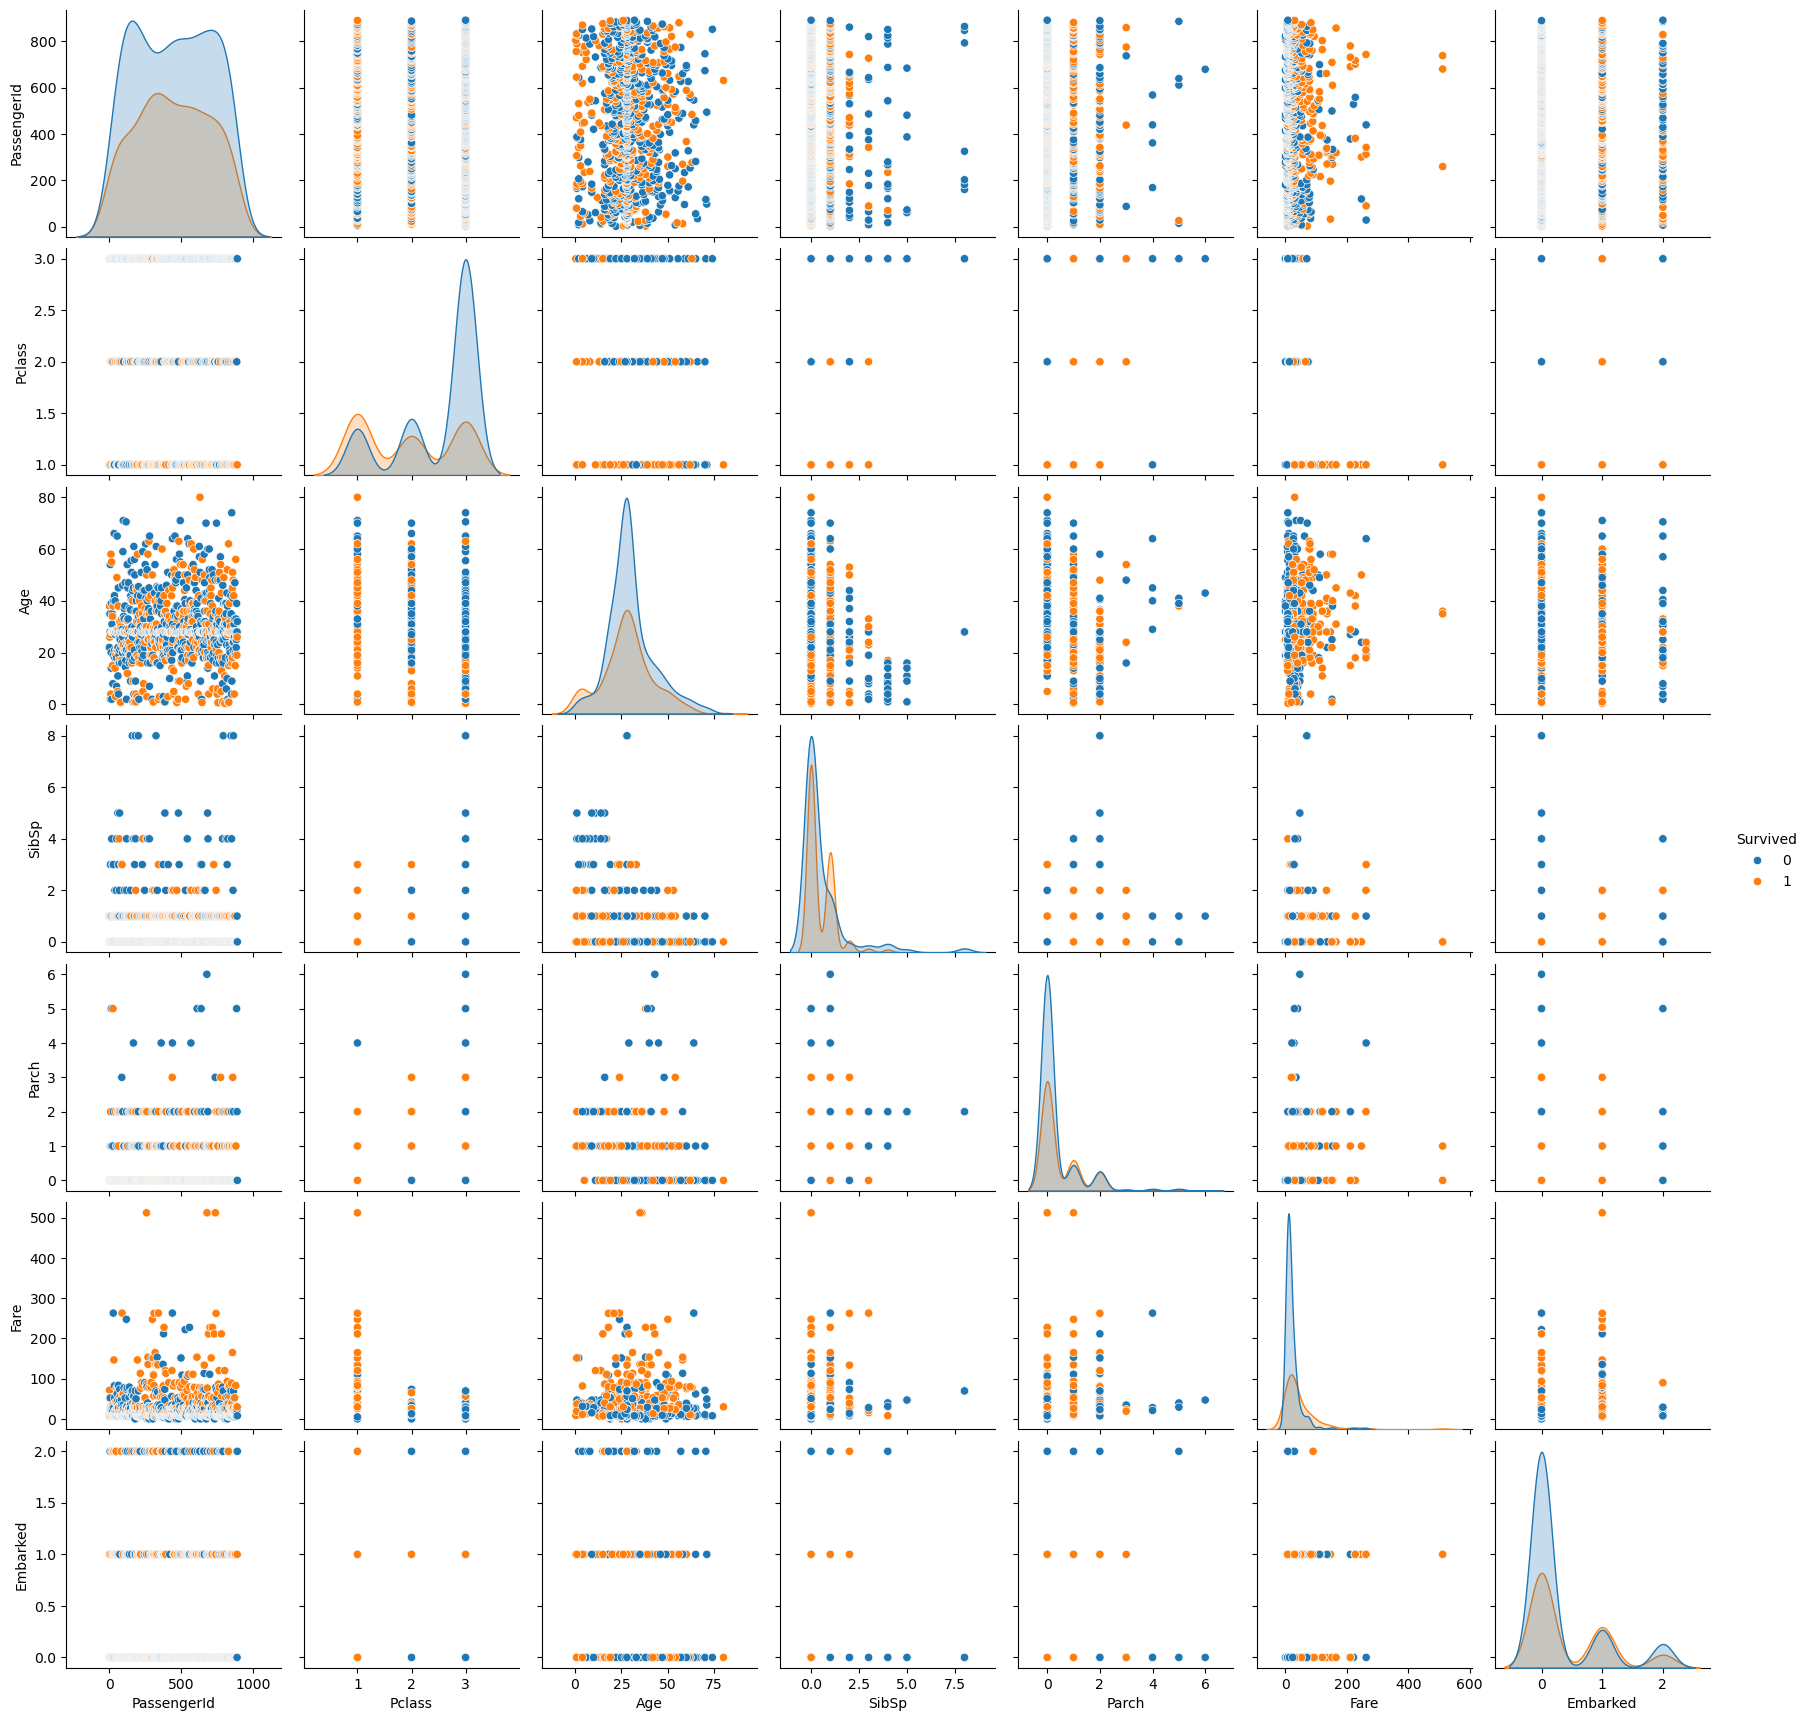

In [10]:
sns.pairplot(df, hue='Survived')
plt.show()

In [11]:
#corr=df.corr()
#sns.heatmap(corr , annot=True , cmap='coolwarm')

In [12]:
df = df.drop(['Parch'], axis=1)


In [13]:
df.dropna(subset=['Embarked'],inplace=True)
Y=df['Survived']
X=df.drop(['Survived'],axis=1)
print(df.isna().sum())

PassengerId    0
Survived       0
Pclass         0
Age            0
SibSp          0
Fare           0
Embarked       0
dtype: int64


In [14]:
print(Y)

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 889, dtype: int64


In [15]:
print(X)


     PassengerId  Pclass   Age  SibSp     Fare  Embarked
0              1       3  22.0      1   7.2500       0.0
1              2       1  38.0      1  71.2833       1.0
2              3       3  26.0      0   7.9250       0.0
3              4       1  35.0      1  53.1000       0.0
4              5       3  35.0      0   8.0500       0.0
..           ...     ...   ...    ...      ...       ...
886          887       2  27.0      0  13.0000       0.0
887          888       1  19.0      0  30.0000       0.0
888          889       3  28.0      1  23.4500       0.0
889          890       1  26.0      0  30.0000       1.0
890          891       3  32.0      0   7.7500       2.0

[889 rows x 6 columns]


In [16]:
x_train,x_test,y_train,y_test=train_test_split(
    X,Y,
    test_size=0.3, 
    random_state=42,
)

In [17]:
#from sklearn.svm import SVC
#from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [18]:
svc_model=LogisticRegression()

In [19]:
svc_model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
y_predic=svc_model.predict(x_test)

In [21]:
# Accuracy
accuracy = accuracy_score(y_test, y_predic)
print(f"\n✅ Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Detailed classification report
print("\n📊 Classification Report:")
print(classification_report(y_test, y_predic))

# Confusion Matrix
print("\n🔢 Confusion Matrix:")
confusion_matrix(y_test, y_predic)



✅ Accuracy: 0.7378 (73.78%)

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.88      0.81       167
           1       0.71      0.50      0.59       100

    accuracy                           0.74       267
   macro avg       0.73      0.69      0.70       267
weighted avg       0.73      0.74      0.73       267


🔢 Confusion Matrix:


array([[147,  20],
       [ 50,  50]])